# Prototipo simulador parte 5A
## Generación de imágenes corregidas para informe final de trabajo de grado

In [9]:
# Librerías
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Estilo
plt.style.use('seaborn-v0_8-whitegrid')

In [10]:
class Paciente:
    """Clase que define un paciente con parámetros normales;
    para agregar pacientes con patologías, crear una subclase con modificaciones
    en los parámetros específicos que haga falta"""
    def __init__(self, R1=5, C1=0.05, R2=10, C2=0.05):
        self.R1 = R1
        self.C1 = C1
        self.R2 = R2
        self.C2 = C2
        self.E1 = 1 / self.C1
        self.E2 = 1 / self.C2

In [11]:
class Ventilador:
    """Parámetros y perfiles de ventilación mecánica."""
    def __init__(self,
                 modo: str = 'PCV',
                 PEEP: float = 5.0,
                 P_driving: float = 15.0,
                 fr: float = 20.0,
                 Ti: float = 1.0,
                 Vt: float = None):
        self.modo = modo
        self.PEEP = PEEP
        self.P_driving = P_driving
        self.fr = fr
        self.Ti = Ti
        self.T_total = 60.0 / fr
        self.Vt = Vt
        if modo == 'VCV':
            assert Vt is not None, "Se requiere Vt para modo VCV"
            self.flow_insp = Vt / Ti
        else:
            self.flow_insp = None

    def presion(self, t: float) -> np.ndarray:
        """Perfil de presión en la vía aérea según el modo y el tiempo t."""
        t_arr = np.asarray(t) 
        en_insp = (t_arr % self.T_total) < self.Ti
        if self.modo == 'PCV':
            P_control = self.PEEP + self.P_driving
            return np.where(en_insp, P_control, self.PEEP)
        elif self.modo == 'VCV':
            return np.full_like(t_arr, self.PEEP)
        else:
            raise ValueError(f"Modo desconocido: {self.modo}")

    def flujo(self, t: float) -> np.ndarray:
        """Perfil de flujo inspirado en VCV, 0 fuera de inspiración."""
        if self.modo != 'VCV':
            return np.zeros_like(np.asarray(t))
        t_arr = np.asarray(t)
        return np.where((t_arr % self.T_total) < self.Ti, self.flow_insp, 0.0)

In [12]:
class Simulador:
    """Orquesta la simulación paciente-ventilador."""
    def __init__(self,
                 paciente: Paciente,
                 ventilador: Ventilador,
                 control: 'ControlRespiratorio' = None):
        self.paciente = paciente
        self.ventilador = ventilador
        self.control = control
        if ventilador.modo == 'ESP':
            assert self.control is not None, "Se requiere un módulo de ControlRespiratorio para el modo 'ESP'"

    def _modelo_edo(self, t, y):
        V1, V2 = y
        R_exp = 5.0
        en_insp = (t % self.ventilador.T_total) < self.ventilador.Ti

        if self.ventilador.modo == 'ESP':
            Pmus = self.control.generar_Pmus(t)
            if Pmus < 0:  # inspiración activa
                P_aw = self.ventilador.PEEP - Pmus
                dV1_dt = (P_aw - self.paciente.E1 * V1) / self.paciente.R1
                dV2_dt = (P_aw - self.paciente.E2 * V2) / self.paciente.R2
            else:  # espiración pasiva con R_exp compartido
                R1, R2 = self.paciente.R1, self.paciente.R2
                A = self.ventilador.PEEP - self.paciente.E1 * V1
                B = self.ventilador.PEEP - self.paciente.E2 * V2
                D = R1*R2 + R1*R_exp + R2*R_exp
                dV1_dt = (A*(R2+R_exp) - B*R_exp) / D
                dV2_dt = (B*(R1+R_exp) - A*R_exp) / D

        elif self.ventilador.modo in ['VCV', 'PCV']:
            if en_insp:
                if self.ventilador.modo == 'VCV':
                    flow_total = self.ventilador.flow_insp
                    P_aw = (flow_total + (self.paciente.E1 * V1 / self.paciente.R1) + (self.paciente.E2 * V2 / self.paciente.R2)) / ((1.0 / self.paciente.R1) + (1.0 / self.paciente.R2))
                else: # PCV
                    P_aw = self.ventilador.PEEP + self.ventilador.P_driving
                
                dV1_dt = (P_aw - self.paciente.E1 * V1) / self.paciente.R1
                dV2_dt = (P_aw - self.paciente.E2 * V2) / self.paciente.R2
            else:
                # Fase Espiratoria: Descarga pasiva compartida a través de R_exp
                A = self.ventilador.PEEP - self.paciente.E1 * V1
                B = self.ventilador.PEEP - self.paciente.E2 * V2
                R1, R2 = self.paciente.R1, self.paciente.R2
                
                D = R1 * R2 + R1 * R_exp + R2 * R_exp
                dV1_dt = (A * (R2 + R_exp) - B * R_exp) / D
                dV2_dt = (B * (R1 + R_exp) - A * R_exp) / D
        else:
            raise ValueError(f"Modo desconocido: {self.ventilador.modo}")

        return [dV1_dt, dV2_dt]

    def _edo_insp(self, t, y):
        """EDO fase inspiratoria: solo se llama en [t0, Ti]."""
        V1, V2 = y
        pac = self.paciente
        vent = self.ventilador
        if vent.modo == 'VCV':
            flow = vent.flow_insp
            P_aw = (flow + pac.E1*V1/pac.R1 + pac.E2*V2/pac.R2) / (1/pac.R1 + 1/pac.R2)
        else:  # PCV
            P_aw = vent.PEEP + vent.P_driving
        return [(P_aw - pac.E1*V1)/pac.R1,
                (P_aw - pac.E2*V2)/pac.R2]

    def _edo_esp(self, t, y):
        """EDO fase espiratoria con R_exp compartido: solo se llama en [Ti, T_total]."""
        V1, V2 = y
        pac = self.paciente
        vent = self.ventilador
        R_exp = 5.0
        A = vent.PEEP - pac.E1*V1
        B = vent.PEEP - pac.E2*V2
        D = pac.R1*pac.R2 + pac.R1*R_exp + pac.R2*R_exp
        return [(A*(pac.R2+R_exp) - B*R_exp)/D,
                (B*(pac.R1+R_exp) - A*R_exp)/D]

    def simular(self,
                num_ciclos: int=15,
                pasos_por_ciclo: int = 100):
        """Ejecuta múltiples ciclos y devuelve t, V1 y V2 concatenados."""
        t_data, V1_data, V2_data = [], [], []
        V0 = [0.0, 0.0]

        if self.ventilador.modo == 'ESP':
            for i in range(num_ciclos):
                t0 = i * self.ventilador.T_total
                t1 = (i + 1) * self.ventilador.T_total
                t_eval = np.linspace(t0, t1, pasos_por_ciclo, endpoint=(i == num_ciclos-1))
                sol = solve_ivp(self._modelo_edo, [t0, t1], V0, t_eval=t_eval)
                t_data.append(sol.t)
                V1_data.append(sol.y[0])
                V2_data.append(sol.y[1])
                V0 = sol.y[:, -1]
        else:
            for i in range(num_ciclos):
                t0   = i * self.ventilador.T_total
                t_Ti = t0 + self.ventilador.Ti
                t1   = t0 + self.ventilador.T_total
                n_insp = max(10, int(pasos_por_ciclo * self.ventilador.Ti / self.ventilador.T_total))
                n_esp  = max(10, pasos_por_ciclo - n_insp)

                t_eval_i = np.linspace(t0, t_Ti, n_insp, endpoint=False)
                sol_i = solve_ivp(self._edo_insp, [t0, t_Ti], V0,
                                  t_eval=t_eval_i, method='RK45', max_step=0.05)

                V_mid = sol_i.y[:, -1]
                t_eval_e = np.linspace(t_Ti, t1, n_esp, endpoint=(i == num_ciclos-1))
                sol_e = solve_ivp(self._edo_esp, [t_Ti, t1], V_mid,
                                  t_eval=t_eval_e, method='RK45', max_step=0.05)

                t_data.extend([sol_i.t, sol_e.t])
                V1_data.extend([sol_i.y[0], sol_e.y[0]])
                V2_data.extend([sol_i.y[1], sol_e.y[1]])
                V0 = sol_e.y[:, -1]

        return np.concatenate(t_data), np.concatenate(V1_data), np.concatenate(V2_data)

    def procesar_resultados(self, t: np.ndarray, V1: np.ndarray, V2: np.ndarray) -> dict:
        """Calcula flujo, volumen total y presión resultante."""
        Vt = V1 + V2
        R_exp = 5.0
        en_insp = (t % self.ventilador.T_total) < self.ventilador.Ti

        if self.ventilador.modo in ['PCV', 'VCV']:
            pac = self.paciente
            vent = self.ventilador
            if vent.modo == 'VCV':
                flow_ctrl = vent.flow_insp * np.ones_like(t)
                P_aw_i = (flow_ctrl + pac.E1*V1/pac.R1 + pac.E2*V2/pac.R2) / (1/pac.R1 + 1/pac.R2)
            else:
                P_aw_i = np.full_like(t, vent.PEEP + vent.P_driving)
            f1_i = (P_aw_i - pac.E1*V1) / pac.R1
            f2_i = (P_aw_i - pac.E2*V2) / pac.R2
            A = vent.PEEP - pac.E1*V1
            B = vent.PEEP - pac.E2*V2
            D = pac.R1*pac.R2 + pac.R1*R_exp + pac.R2*R_exp
            f1_e = (A*(pac.R2+R_exp) - B*R_exp) / D
            f2_e = (B*(pac.R1+R_exp) - A*R_exp) / D
            flujo1 = np.where(en_insp, f1_i, f1_e)
            flujo2 = np.where(en_insp, f2_i, f2_e)
        else:  # ESP: flujo analítico por fase
            pac = self.paciente
            vent = self.ventilador
            Pmus_arr      = self.control.generar_Pmus(t)
            en_insp_esp   = Pmus_arr < 0
            P_eff_insp    = vent.PEEP - Pmus_arr
            P_aw_insp_esp = vent.PEEP + Pmus_arr
            f1_i = (P_eff_insp - pac.E1*V1) / pac.R1
            f2_i = (P_eff_insp - pac.E2*V2) / pac.R2
            A = vent.PEEP - pac.E1*V1
            B = vent.PEEP - pac.E2*V2
            D = pac.R1*pac.R2 + pac.R1*R_exp + pac.R2*R_exp
            f1_e = (A*(pac.R2+R_exp) - B*R_exp) / D
            f2_e = (B*(pac.R1+R_exp) - A*R_exp) / D
            flujo1 = np.where(en_insp_esp, f1_i, f1_e)
            flujo2 = np.where(en_insp_esp, f2_i, f2_e)
        flujo_total = flujo1 + flujo2
        
        # Cálculo de presiones por fase usando vectorización
        P_aw_esp = self.ventilador.PEEP - (flujo_total * R_exp)
        P_aw_insp_vcv = (flujo_total + (self.paciente.E1 * V1 / self.paciente.R1) + (self.paciente.E2 * V2 / self.paciente.R2)) / ((1.0 / self.paciente.R1) + (1.0 / self.paciente.R2))
        P_aw_insp_pcv = self.ventilador.PEEP + self.ventilador.P_driving
        
        if self.ventilador.modo == 'VCV':
            P_aw = np.where(en_insp, P_aw_insp_vcv, P_aw_esp)
        elif self.ventilador.modo == 'PCV':
            P_aw = np.where(en_insp, P_aw_insp_pcv, P_aw_esp)
        else:  # ESP
            P_aw = np.where(en_insp_esp, P_aw_insp_esp, P_aw_esp)

        return {
            't': t, 'V1': V1, 'V2': V2, 'Vt': Vt,
            'flow1': flujo1, 'flow2': flujo2, 'flow': flujo_total, 'P_aw': P_aw
        }

    def graficar_resultados(self,
                            resultados: dict,
                            titulo: str = 'Simulación Pulmonar'):
        """Grafica presión, flujo total y volumen total a partir del diccionario
        de resultados."""
        t = resultados['t']
        P_aw = resultados['P_aw']
        flujo = resultados['flow']
        Vt = resultados['Vt']

        fig, axs = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
        fig.suptitle(titulo, fontsize=16)

        # Presión
        axs[0].plot(t, P_aw, color='red', label='Presión (P_aw)')
        axs[0].set_ylabel('Presión (cmH2O)')
        axs[0].legend()

        # Flujo
        axs[1].plot(t, flujo, color='blue', label='Flujo Total')
        axs[1].set_ylabel('Flujo (L/s)')
        axs[1].axhline(0, color='grey', linewidth=0.8)
        axs[1].legend()

        # Volumen
        axs[2].plot(t, Vt, color='green', label='Volumen (L)')
        axs[2].set_ylabel('Volumen (L)')
        axs[2].set_xlabel('Tiempo (s)')
        axs[2].legend()

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()


In [13]:
class IntercambioGases:
    """
    Módulo de intercambio gaseoso alveolar.
    Calcula presiones de CO2 y O2 alveolares a partir de los resultados
    de la simulación de mecánica respiratoria.
    """
    def __init__(
        self,
        ventilador,
        V_D: float,
        VCO2: float,
        R: float,
        FiO2: float,
        Pb: float,
        PH2O: float = 47.0,
        K: float = 0.863
    ):
        self.ventilador = ventilador
        self.V_D = V_D      # volumen muerto anatómico (L)
        self.VCO2 = VCO2    # producción de CO2 (mL/min)
        self.R = R          # cociente respiratorio (adimensional)
        self.FiO2 = FiO2    # fracción inspirada de O2 (0-1)
        self.Pb = Pb        # presión barométrica (mmHg)
        self.PH2O = PH2O    # presión vapor de agua a 37°C (mmHg)
        self.K = K          # constante de conversión de unidades

    def calcular(self, resultados: dict) -> dict:
        """
        Ejecuta el cálculo de intercambio gaseoso.

        Parámetros
        ----------
        resultados : dict
            Diccionario de salida de Simulador.procesar_resultados(),
            con claves 't' (tiempo) y 'Vt' (volumen total alveolar, L).

        Devuelve
        -------
        dict con:
            VE_min: ventilación minuto total (L/min)
            VA_min: ventilación minuto alveolar (L/min)
            PACO2_mmHg: presión alveolar de CO2 (mmHg)
            PAO2_mmHg: presión alveolar de O2 (mmHg)
        """
        t = resultados['t']
        # 1. Frecuencia respiratoria (ciclos/min)
        f = self.ventilador.fr

        # 2. Volumen tidal (L)
        if self.ventilador.modo == 'VCV':
            VT = self.ventilador.Vt
        else:
            # Para modos espontáneos o PCV, calculamos el VT promedio
            # integrando el flujo inspiratorio sobre el período de simulación.
            flujo = resultados['flow']

            # 1. Identificar el flujo inspiratorio
            flujo_inspiratorio = np.maximum(0, flujo)

            # 2. Integrar el flujo para obtener el volumen total inspirado en el chunk
            volumen_inspirado_total = np.trapz(flujo_inspiratorio, t)

            # 3. Calcular el número de respiraciones en el chunk
            duracion_chunk = t[-1] - t[0]
            num_respiraciones = duracion_chunk * (f / 60.0) # f está en rpm, t en seg

            # 4. Calcular el VT promedio (evitando división por cero)
            if num_respiraciones > 0:
                VT = volumen_inspirado_total / num_respiraciones
            else:
                VT = 0

        # 3. Ventilaciones minuto
        VE = VT * f
        VA = (VT - self.V_D) * f

        if VA <= 0:  #ocurre sólo si el VT es realmente muy bajo.
            raise ValueError("Ventilación alveolar ≤ 0, revisa V_D o simulación.")

        # 4. Presión alveolar de CO2 (mmHg)
        PACO2 = (self.VCO2 * self.K) / VA

        # 5. Presión alveolar de O2 (mmHg)
        PIO2 = self.FiO2 * (self.Pb - self.PH2O)
        PAO2 = PIO2 - (PACO2 / self.R)

        return {
            'VE_min': VE,
            'VA_min': VA,
            'PACO2_mmHg': PACO2,
            'PAO2_mmHg': PAO2
        }


In [14]:
class InteraccionCorazonPulmon:
    """
    Módulo de interacción corazón-pulmón.

    Modela el efecto de la presión en la vía aérea sobre el gasto cardíaco y la
    entrega de oxígeno.
    """
    def __init__(
        self,
        GC_base_L_min: float = 5.0,
        k_sensibilidad: float = 0.1,
        hb_g_dl: float = 15.0
    ):
        self.GC_base_L_min = GC_base_L_min
        self.k_sensibilidad = k_sensibilidad
        self.hb_g_dl = hb_g_dl
        # Constantes fisiológicas
        self.O2_CAP_HB = 1.34  # Capacidad de O2 por gramo de Hb (mL O2/g Hb)
        self.O2_SOL_PLASMA = 0.003  # Solubilidad de O2 en plasma (mL O2/dL/mmHg)

    def _estimar_sao2(self, pao2: float) -> float:
        """
        Estima la SaO2 a partir de la PaO2 usando la ecuación empírica de Severinghaus,
        que modela la curva de disociación sigmoide de la hemoglobina.
        Retorna un valor fraccionario (0.0 a 1.0).
        """
        # Se evita el cero absoluto para prevenir errores de división
        p = max(pao2, 0.1)
        sao2 = 1.0 / ((23400.0 / (p**3 + 150.0 * p)) + 1.0)
        return sao2

    def calcular(
        self,
        resultados_mecanica: dict,
        resultados_gases: dict,
        ventilador: Ventilador
    ) -> dict:
        """Calcula el impacto hemodinámico de la ventilación mecánica."""
        t = resultados_mecanica['t']
        P_aw = resultados_mecanica['P_aw']
        PAO2_mmHg = resultados_gases['PAO2_mmHg']

        # 1. Calcular Presión Media en la Vía Aérea (P_mean)
        # Se usa el T_total del ventilador para aislar exactamente el último ciclo
        tiempo_total_ciclo = ventilador.T_total
        p_aw_ultimo_ciclo = P_aw[t >= (t[-1] - tiempo_total_ciclo)]
        t_ultimo_ciclo = t[t >= (t[-1] - tiempo_total_ciclo)]

        area_bajo_curva = np.trapz(p_aw_ultimo_ciclo, t_ultimo_ciclo)
        P_mean = area_bajo_curva / (t_ultimo_ciclo[-1] - t_ultimo_ciclo[0])

        # 2. Calcular Gasto Cardíaco Actual
        PEEP_base = ventilador.PEEP
        delta_p = P_mean - PEEP_base
        reduccion_gc = self.k_sensibilidad * delta_p
        GC_actual = self.GC_base_L_min - reduccion_gc
        
        # Asegurar que el GC no sea negativo
        GC_actual = max(0, GC_actual)

        # 3. Calcular Contenido Arterial de O2 (CAO2)
        # Se asume un gradiente Alveolo-arterial de O2 de 10 mmHg
        PaO2 = PAO2_mmHg - 10.0
        SaO2 = self._estimar_sao2(PaO2)

        # CAO2 = (Hb * SaO2 * 1.34) + (PaO2 * 0.003)
        O2_unido_hb = self.hb_g_dl * SaO2 * self.O2_CAP_HB
        O2_disuelto = PaO2 * self.O2_SOL_PLASMA
        CAO2_ml_dl = O2_unido_hb + O2_disuelto

        # 4. Entrega de Oxígeno (DO2)
        # DO2 (mL/min) = GC (L/min) * CAO2 (mL/dL) * 10 (dL/L)
        DO2_ml_min = GC_actual * CAO2_ml_dl * 10.0

        return {
            'P_mean_cmH2O': P_mean,
            'GC_actual_L_min': GC_actual,
            'PaO2_mmHg': PaO2,
            'SaO2_percent': SaO2 * 100.0,
            'CAO2_ml_dl': CAO2_ml_dl,
            'DO2_ml_min': DO2_ml_min
        }


In [15]:
class ControlRespiratorio:
    """
    Modelo de control respiratorio Proporcional-Integral (PI).

    Ajusta la amplitud y frecuencia de la presión muscular (Pmus)
    en función del error entre la PaCO2 actual (aproximada como PACO2)
    y un valor de referencia (PACO2_target).

    Ecuaciones:
        A = amplitud_base + Gp * (PACO2 - PACO2_target) + Gi * integral_error
        f = clamp(f_base + Gf * (PACO2 - PACO2_target), 6, 40)  [rpm]

    Métodos
    -------
    actualizar(PACO2, dt)
        Recalcula amplitud y frecuencia a partir de la PACO2 medida.
    generar_Pmus(t)
        Genera la señal Pmus(t) como cuarto de seno creciente durante Ti.
    """
    def __init__(self,
                 PACO2_target: float = 40.0,
                 f_base: float = 15.0,
                 amplitud_base: float = 5.0,
                 Gp: float = 0.1,
                 Gf: float = 0.15,
                 Gi: float = 0.05):
        self.PACO2_target  = PACO2_target
        self.f_base        = f_base
        self.amplitud_base = amplitud_base   # esfuerzo mínimo garantizado (cmH2O)
        self.Gp = Gp
        # Convertir Gf de (ciclos/min)/mmHg a Hz/mmHg
        self.Gf = Gf / 60.0
        self.Gi = Gi
        self.integral_error = 0.0
        # Estado inicial a valores base (no None)
        self.amplitud   = amplitud_base
        self.frecuencia = f_base / 60.0

    def actualizar(self, PACO2: float, dt: float):
        """
        Actualiza la amplitud y frecuencia de Pmus en base a la PACO2.
        """
        error = PACO2 - self.PACO2_target
        self.integral_error += error * dt
        # Anti-windup
        self.integral_error = min(max(self.integral_error, -100.0), 100.0)

        amplitud_calculada = self.amplitud_base + (self.Gp * error) + (self.Gi * self.integral_error)
        amp_saturada = min(max(0.0, amplitud_calculada), 25.0)
        self.amplitud = 0.7 * self.amplitud + 0.3 * amp_saturada

        # Frecuencia: saturada entre 6 y 40 rpm (límites fisiológicos)
        self.frecuencia = max(6.0 / 60.0, min(40.0 / 60.0, self.f_base / 60.0 + self.Gf * error))
        return self.amplitud, self.frecuencia

    def generar_Pmus(self, t: np.ndarray) -> np.ndarray:
        """
        Genera la señal de presión muscular como cuarto de seno creciente:
          Pmus = -amplitud * sin(π/2 * t_ciclo/Ti)  durante inspiración (Ti = T/2)
          Pmus = 0                                   durante espiración pasiva

        Parámetros
        ----------
        t : np.ndarray  Vector de tiempos en segundos.

        Retorna
        -------
        np.ndarray  Señal Pmus en cmH2O.
        """
        T_ciclo    = 1.0 / self.frecuencia
        Ti         = T_ciclo / 2.0
        t_arr      = np.asarray(t, dtype=float)
        t_en_ciclo = t_arr % T_ciclo
        en_insp    = t_en_ciclo < Ti
        fase       = t_en_ciclo / Ti          # 0 → 1 durante inspiración
        Pmus_insp  = -self.amplitud * np.sin(np.pi / 2.0 * fase)
        return np.where(en_insp, Pmus_insp, 0.0)


## Gráficas

In [16]:
# Bloque de estilos
C_PRESION = '#C0392B'   # rojo vino  – presión
C_FLUJO   = '#2471A3'   # azul acero – flujo
C_VOLUMEN = '#1E8449'   # verde      – volumen
C_COMP1   = '#884EA0'   # morado     – compartimiento 1
C_COMP2   = '#D35400'   # naranja    – compartimiento 2
C_REF     = '#888888'   # gris       – referencias

def _est(ax):
    ax.set_facecolor('white')
    ax.grid(True, color='#D5D5D5', linewidth=0.5, linestyle='-', zorder=0)
    ax.spines[['top', 'right']].set_visible(False)

plt.rcParams.update({'figure.facecolor': 'white', 'font.size': 10})

/var/folders/fj/m5l0ynr5059cvdqxm37ypbmc0000gn/T/ipykernel_61899/2985823188.py:43: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/julianquintana/opt/anaconda3/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


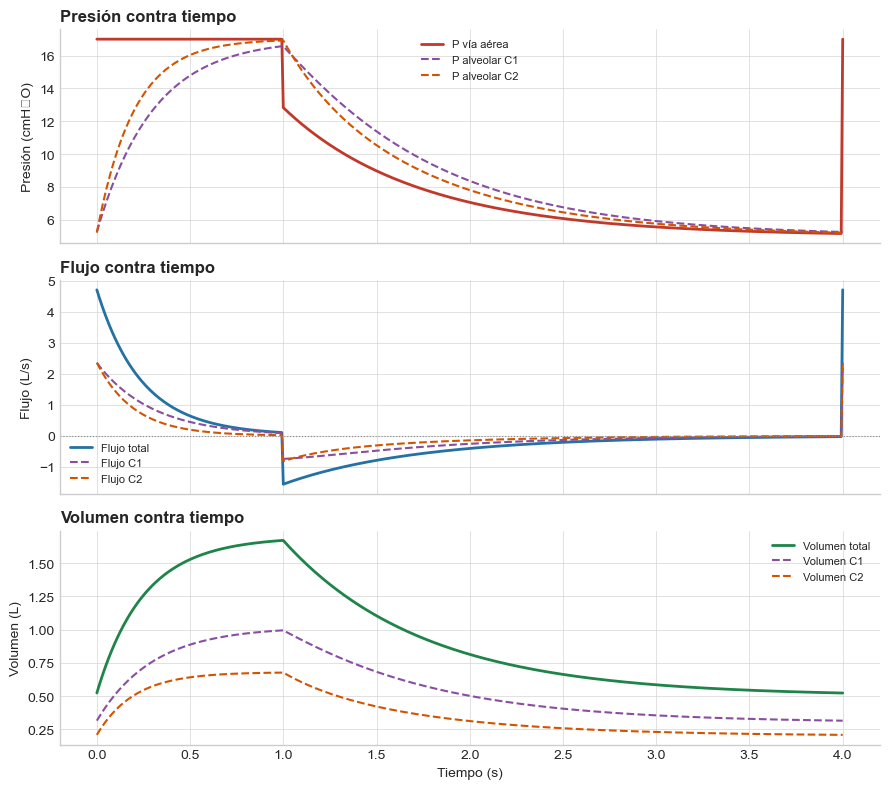

In [17]:
# Figura 18 — PCV ciclo único con compartimientos:

pac  = Paciente(R1=5.0, C1=0.06, R2=5.0, C2=0.04)
vent = Ventilador(modo='PCV', PEEP=5.0, P_driving=12.0, Ti=1.0, fr=15.0)
sim  = Simulador(pac, vent)

t_a, V1a, V2a = sim.simular(num_ciclos=5, pasos_por_ciclo=500)
mk  = t_a >= t_a[-1] - vent.T_total
t   = t_a[mk] - t_a[mk][0]
V1  = V1a[mk];  V2 = V2a[mk]
res = sim.procesar_resultados(t, V1, V2)

Palv1 = pac.E1 * V1
Palv2 = pac.E2 * V2

fig18, axs = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for ax in axs:
    _est(ax)

axs[0].plot(t, res['P_aw'], color=C_PRESION, lw=2.0, label='P vía aérea')
axs[0].plot(t, Palv1, color=C_COMP1, lw=1.5, ls='--', label='P alveolar C1')
axs[0].plot(t, Palv2, color=C_COMP2, lw=1.5, ls='--', label='P alveolar C2')
axs[0].set_ylabel('Presión (cmH₂O)')
axs[0].set_title('Presión contra tiempo', loc='left', fontweight='bold')
axs[0].legend(fontsize=8)

axs[1].plot(t, res['flow'],  color=C_FLUJO, lw=2.0, label='Flujo total')
axs[1].plot(t, res['flow1'], color=C_COMP1, lw=1.5, ls='--', label='Flujo C1')
axs[1].plot(t, res['flow2'], color=C_COMP2, lw=1.5, ls='--', label='Flujo C2')
axs[1].axhline(0, color=C_REF, lw=0.8, ls=':')
axs[1].set_ylabel('Flujo (L/s)')
axs[1].set_title('Flujo contra tiempo', loc='left', fontweight='bold')
axs[1].legend(fontsize=8)

axs[2].plot(t, res['Vt'], color=C_VOLUMEN, lw=2.0, label='Volumen total')
axs[2].plot(t, V1, color=C_COMP1, lw=1.5, ls='--', label='Volumen C1')
axs[2].plot(t, V2, color=C_COMP2, lw=1.5, ls='--', label='Volumen C2')
axs[2].set_ylabel('Volumen (L)')
axs[2].set_xlabel('Tiempo (s)')
axs[2].set_title('Volumen contra tiempo', loc='left', fontweight='bold')
axs[2].legend(fontsize=8)

plt.tight_layout()
# fig18.savefig('/Users/julianquintana/Desktop/figura_18.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/fj/m5l0ynr5059cvdqxm37ypbmc0000gn/T/ipykernel_61899/802199892.py:43: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()


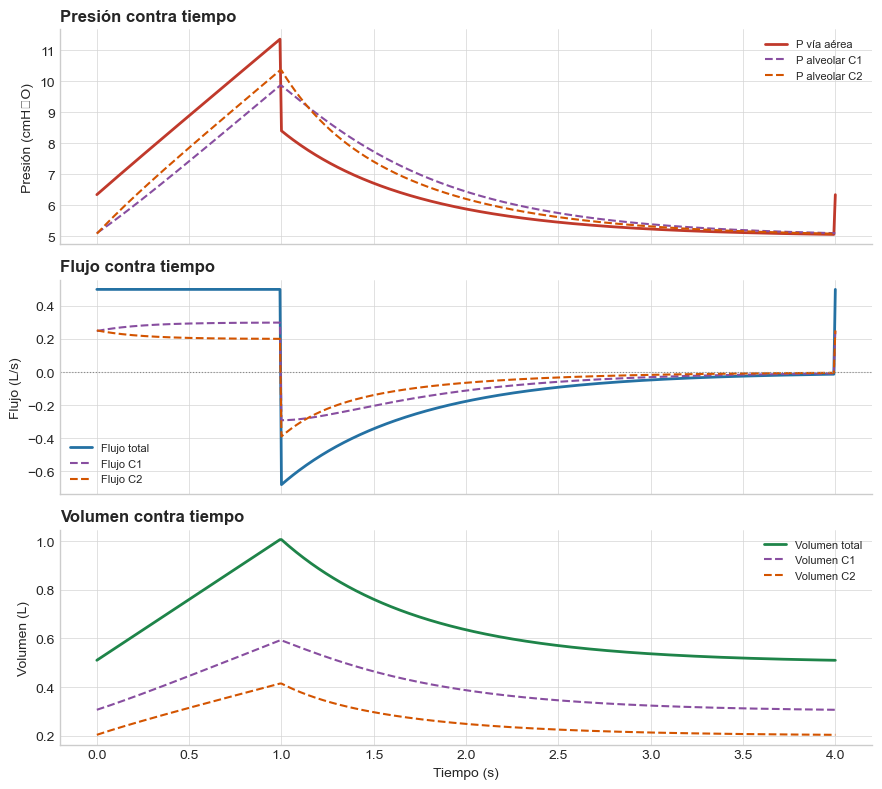

In [18]:
# Figura 19 — VCV ciclo único con compartimientos:

pac  = Paciente(R1=5.0, C1=0.06, R2=5.0, C2=0.04)
vent = Ventilador(modo='VCV', PEEP=5.0, Vt=0.5, Ti=1.0, fr=15.0)
sim  = Simulador(pac, vent)

t_a, V1a, V2a = sim.simular(num_ciclos=5, pasos_por_ciclo=500)
mk  = t_a >= t_a[-1] - vent.T_total
t   = t_a[mk] - t_a[mk][0]
V1  = V1a[mk];  V2 = V2a[mk]
res = sim.procesar_resultados(t, V1, V2)

Palv1 = pac.E1 * V1
Palv2 = pac.E2 * V2

fig19, axs = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for ax in axs:
    _est(ax)

axs[0].plot(t, res['P_aw'], color=C_PRESION, lw=2.0, label='P vía aérea')
axs[0].plot(t, Palv1, color=C_COMP1, lw=1.5, ls='--', label='P alveolar C1')
axs[0].plot(t, Palv2, color=C_COMP2, lw=1.5, ls='--', label='P alveolar C2')
axs[0].set_ylabel('Presión (cmH₂O)')
axs[0].set_title('Presión contra tiempo', loc='left', fontweight='bold')
axs[0].legend(fontsize=8)

axs[1].plot(t, res['flow'],  color=C_FLUJO, lw=2.0, label='Flujo total')
axs[1].plot(t, res['flow1'], color=C_COMP1, lw=1.5, ls='--', label='Flujo C1')
axs[1].plot(t, res['flow2'], color=C_COMP2, lw=1.5, ls='--', label='Flujo C2')
axs[1].axhline(0, color=C_REF, lw=0.8, ls=':')
axs[1].set_ylabel('Flujo (L/s)')
axs[1].set_title('Flujo contra tiempo', loc='left', fontweight='bold')
axs[1].legend(fontsize=8)

axs[2].plot(t, res['Vt'], color=C_VOLUMEN, lw=2.0, label='Volumen total')
axs[2].plot(t, V1, color=C_COMP1, lw=1.5, ls='--', label='Volumen C1')
axs[2].plot(t, V2, color=C_COMP2, lw=1.5, ls='--', label='Volumen C2')
axs[2].set_ylabel('Volumen (L)')
axs[2].set_xlabel('Tiempo (s)')
axs[2].set_title('Volumen contra tiempo', loc='left', fontweight='bold')
axs[2].legend(fontsize=8)

plt.tight_layout()
# fig19.savefig('/Users/julianquintana/Desktop/figura_19.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/fj/m5l0ynr5059cvdqxm37ypbmc0000gn/T/ipykernel_61899/3912965499.py:43: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()


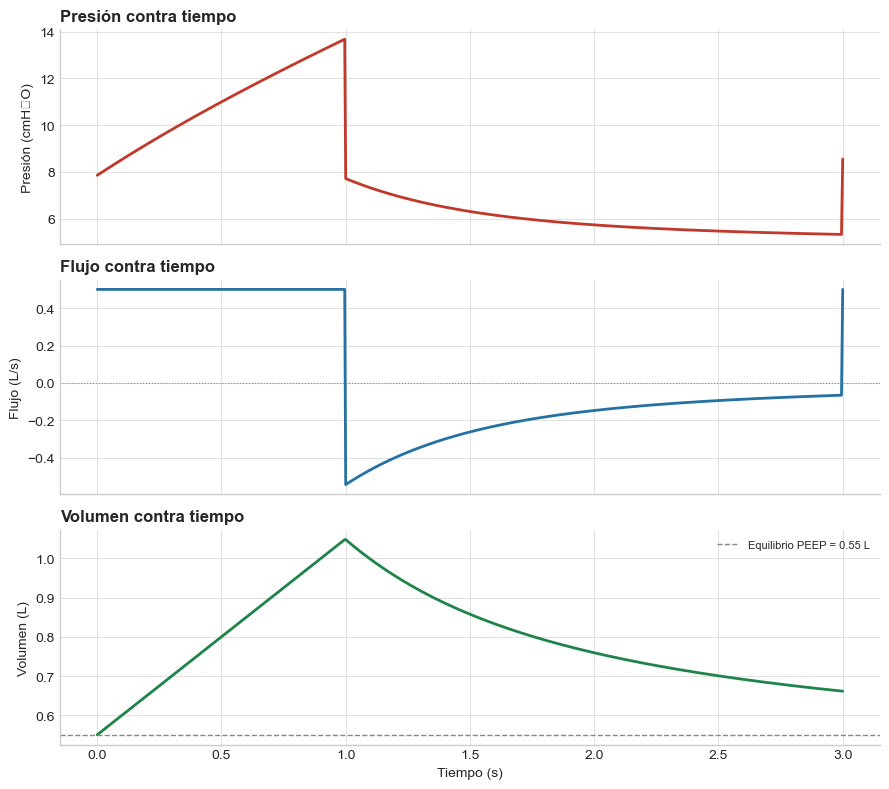

In [19]:
# Figura 20 — VCV en EPOC, ciclo único:

pac  = Paciente(R1=20.0, C1=0.07, R2=8.0, C2=0.04)
vent = Ventilador(modo='VCV', PEEP=5.0, Vt=0.5, Ti=1.0, fr=20.0)
sim  = Simulador(pac, vent)

V0   = [vent.PEEP * pac.C1, vent.PEEP * pac.C2]
V_eq = vent.PEEP * (pac.C1 + pac.C2)

sol_i = solve_ivp(sim._edo_insp, [0, vent.Ti], V0,
                t_eval=np.linspace(0, vent.Ti, 250, endpoint=False),
                method='RK45', max_step=0.01)
sol_e = solve_ivp(sim._edo_esp, [vent.Ti, vent.T_total], sol_i.y[:, -1],
                t_eval=np.linspace(vent.Ti, vent.T_total, 400, endpoint=True),
                method='RK45', max_step=0.01)

t  = np.concatenate([sol_i.t, sol_e.t])
V1 = np.concatenate([sol_i.y[0], sol_e.y[0]])
V2 = np.concatenate([sol_i.y[1], sol_e.y[1]])
res = sim.procesar_resultados(t, V1, V2)

fig20, axs = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for ax in axs:
  _est(ax)

axs[0].plot(t, res['P_aw'], color=C_PRESION, lw=2.0)
axs[0].set_ylabel('Presión (cmH₂O)')
axs[0].set_title('Presión contra tiempo', loc='left', fontweight='bold')

axs[1].plot(t, res['flow'], color=C_FLUJO, lw=2.0)
axs[1].axhline(0, color=C_REF, lw=0.8, ls=':')
axs[1].set_ylabel('Flujo (L/s)')
axs[1].set_title('Flujo contra tiempo', loc='left', fontweight='bold')

axs[2].plot(t, res['Vt'], color=C_VOLUMEN, lw=2.0)
axs[2].axhline(V_eq, color=C_REF, lw=1.0, ls='--',
             label=f'Equilibrio PEEP = {V_eq:.2f} L')
axs[2].set_ylabel('Volumen (L)')
axs[2].set_xlabel('Tiempo (s)')
axs[2].set_title('Volumen contra tiempo', loc='left', fontweight='bold')
axs[2].legend(fontsize=8)

plt.tight_layout()
# fig20.savefig('/Users/julianquintana/Desktop/figura_20.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/fj/m5l0ynr5059cvdqxm37ypbmc0000gn/T/ipykernel_61899/1480604141.py:52: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()


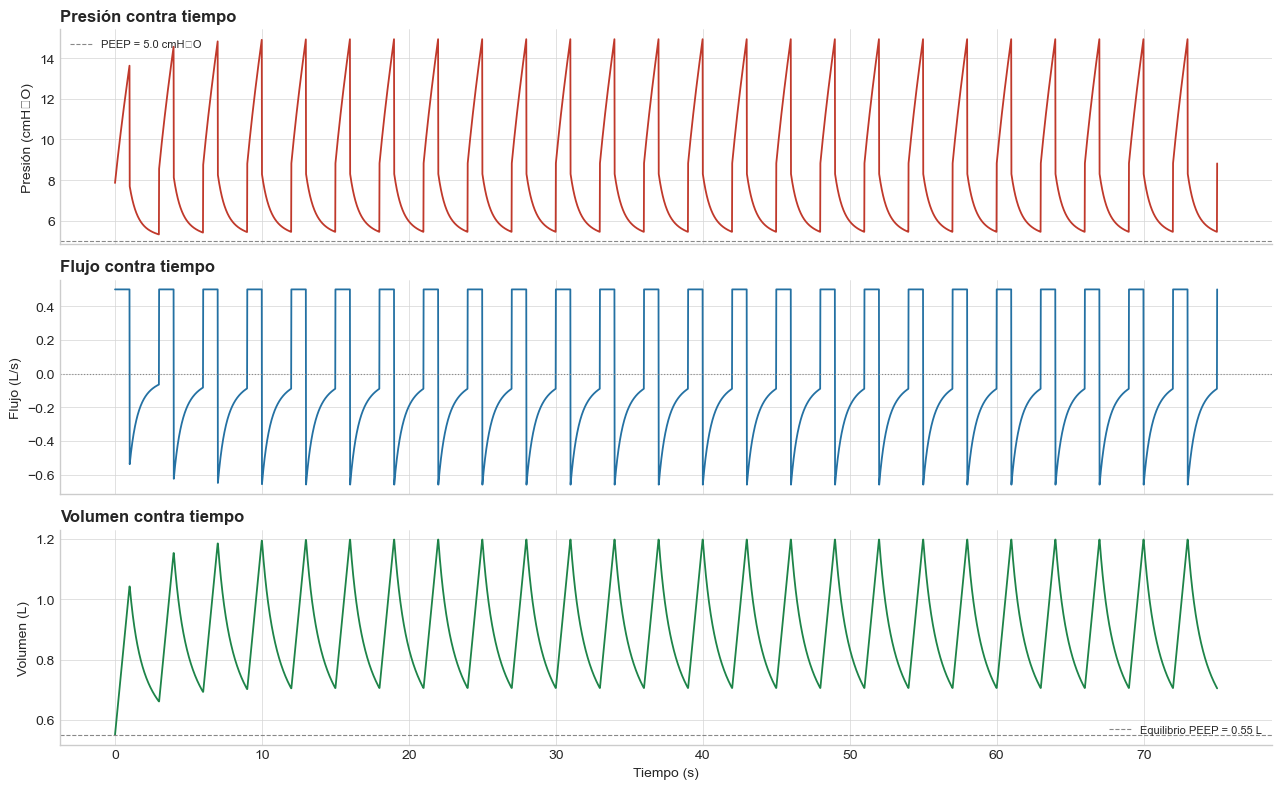

In [23]:
# Figura 21 — Múltiples ciclos en EPOC:

pac  = Paciente(R1=20.0, C1=0.07, R2=8.0, C2=0.04)
vent = Ventilador(modo='VCV', PEEP=5.0, Vt=0.5, Ti=1.0, fr=20.0)
sim  = Simulador(pac, vent)

N    = 25;  ppc = 200
V0   = [vent.PEEP * pac.C1, vent.PEEP * pac.C2]
V_eq = vent.PEEP * (pac.C1 + pac.C2)
Ti   = vent.Ti;  Tt = vent.T_total

ts, V1s, V2s = [], [], []
for i in range(N):
    t0  = i * Tt;  tTi = t0 + Ti;  t1 = (i + 1) * Tt
    ni  = max(10, int(ppc * Ti / Tt));  ne = max(10, ppc - ni)
    si = solve_ivp(sim._edo_insp, [t0, tTi], V0,
                   t_eval=np.linspace(t0, tTi, ni, endpoint=False),
                   method='RK45', max_step=0.02)
    se = solve_ivp(sim._edo_esp, [tTi, t1], si.y[:, -1],
                   t_eval=np.linspace(tTi, t1, ne, endpoint=(i == N - 1)),
                   method='RK45', max_step=0.02)
    ts.extend([si.t, se.t]);  V1s.extend([si.y[0], se.y[0]])
    V2s.extend([si.y[1], se.y[1]]);  V0 = se.y[:, -1]

t  = np.concatenate(ts);  V1 = np.concatenate(V1s);  V2 = np.concatenate(V2s)
res = sim.procesar_resultados(t, V1, V2)

fig21, axs = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
for ax in axs:
    _est(ax)

axs[0].plot(t, res['P_aw'], color=C_PRESION, lw=1.3)
axs[0].axhline(vent.PEEP, color=C_REF, lw=0.8, ls='--',
             label=f'PEEP = {vent.PEEP} cmH₂O')
axs[0].set_ylabel('Presión (cmH₂O)')
axs[0].set_title('Presión contra tiempo', loc='left', fontweight='bold')
axs[0].legend(fontsize=8)

axs[1].plot(t, res['flow'], color=C_FLUJO, lw=1.3)
axs[1].axhline(0, color=C_REF, lw=0.8, ls=':')
axs[1].set_ylabel('Flujo (L/s)')
axs[1].set_title('Flujo contra tiempo', loc='left', fontweight='bold')

axs[2].plot(t, res['Vt'], color=C_VOLUMEN, lw=1.3)
axs[2].axhline(V_eq, color=C_REF, lw=0.8, ls='--',
             label=f'Equilibrio PEEP = {V_eq:.2f} L')
axs[2].set_ylabel('Volumen (L)')
axs[2].set_xlabel('Tiempo (s)')
axs[2].set_title('Volumen contra tiempo', loc='left', fontweight='bold')
axs[2].legend(fontsize=8)

plt.tight_layout()
# fig21.savefig('/Users/julianquintana/Desktop/figura_21.png', dpi=150, bbox_inches='tight')
plt.show()

--- RESULTADOS DE LA SIMULACIÓN INTEGRAL ---

--- Parámetros del Ventilador ---
Modo: PCV, PEEP: 5.0 cmH2O, P_driving: 12.0 cmH2O, FR: 15.0/min

--- Resultados de Mecánica Ventilatoria (último ciclo) ---
Volumen Tidal (Vt) entregado: 1.16 L
Presión Pico: 17.0 cmH2O

--- Resultados de Intercambio Gaseoso ---
Ventilación Minuto Total (VE): 17.88 L/min
Ventilación Minuto Alveolar (VA): 15.63 L/min
Presión Alveolar de CO2 (PACO2): 11.0 mmHg
Presión Alveolar de O2 (PAO2): 135.9 mmHg

--- Resultados de Interacción Corazón-Pulmón ---
Presión Media en Vía Aérea (P_mean): 9.5 cmH2O
Gasto Cardíaco Basal: 5.0 L/min  -->  Gasto Cardíaco Actual: 4.64 L/min
PaO2 estimada: 125.9 mmHg
SaO2 estimada: 98.9%
Contenido Arterial de O2 (CAO2): 20.25 mL/dL
Entrega de Oxígeno a Tejidos (DO2): 940.2 mL/min


/var/folders/fj/m5l0ynr5059cvdqxm37ypbmc0000gn/T/ipykernel_61899/4050839346.py:78: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()


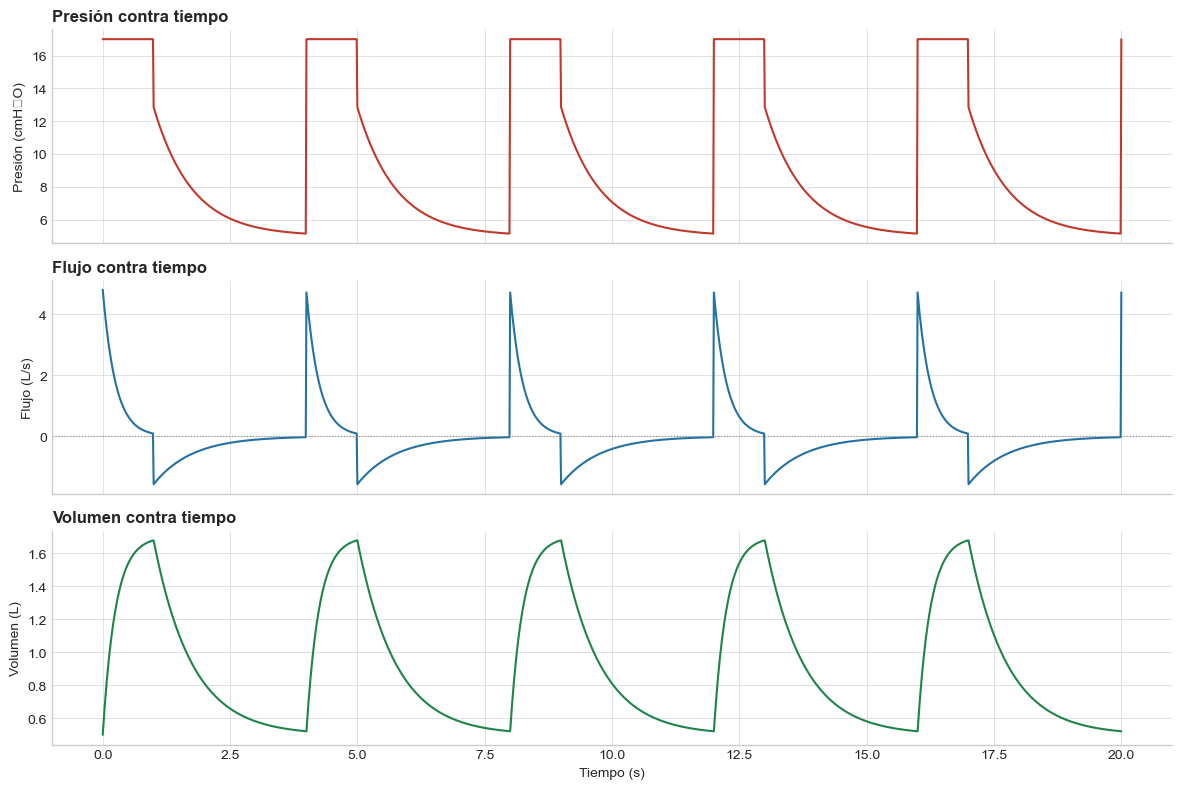

In [25]:
# Figura 22 — PCV con interacción corazón-pulmón:

pac    = Paciente(R1=5.0, C1=0.05, R2=5.0, C2=0.05)
vent   = Ventilador(modo='PCV', PEEP=5.0, P_driving=12.0, Ti=1.0, fr=15.0)
sim    = Simulador(pac, vent)
gases  = IntercambioGases(vent, V_D=0.150, VCO2=200.0, R=0.8, FiO2=0.21, Pb=760.0)
cardio = InteraccionCorazonPulmon(GC_base_L_min=5.0, k_sensibilidad=0.08, hb_g_dl=15.0)

N_22 = 5;  ppc_22 = 300
V0_22 = [vent.PEEP * pac.C1, vent.PEEP * pac.C2]
ts22, V1s22, V2s22 = [], [], []
for i in range(N_22):
    t0  = i * vent.T_total;  tTi = t0 + vent.Ti;  t1 = (i + 1) * vent.T_total
    ni  = max(10, int(ppc_22 * vent.Ti / vent.T_total));  ne = max(10, ppc_22 - ni)
    si = solve_ivp(sim._edo_insp, [t0, tTi], V0_22,
                   t_eval=np.linspace(t0, tTi, ni, endpoint=False),
                   method='RK45', max_step=0.01)
    se = solve_ivp(sim._edo_esp, [tTi, t1], si.y[:, -1],
                   t_eval=np.linspace(tTi, t1, ne, endpoint=(i == N_22 - 1)),
                   method='RK45', max_step=0.01)
    ts22.extend([si.t, se.t]);  V1s22.extend([si.y[0], se.y[0]])
    V2s22.extend([si.y[1], se.y[1]]);  V0_22 = se.y[:, -1]

t22  = np.concatenate(ts22)
V122 = np.concatenate(V1s22);  V222 = np.concatenate(V2s22)
res22 = sim.procesar_resultados(t22, V122, V222)

rg22  = gases.calcular(res22)
rc22  = cardio.calcular(res22, rg22, vent)

mk_lc   = t22 >= t22[-1] - vent.T_total
VT22    = res22['Vt'][mk_lc].max() - res22['Vt'][mk_lc].min()
Ppico22 = res22['P_aw'][mk_lc].max()

print('--- RESULTADOS DE LA SIMULACIÓN INTEGRAL ---')
print()
print('--- Parámetros del Ventilador ---')
print(f"Modo: {vent.modo}, PEEP: {vent.PEEP} cmH2O, "
    f"P_driving: {vent.P_driving} cmH2O, FR: {vent.fr}/min")
print()
print('--- Resultados de Mecánica Ventilatoria (último ciclo) ---')
print(f"Volumen Tidal (Vt) entregado: {VT22:.2f} L")
print(f"Presión Pico: {Ppico22:.1f} cmH2O")
print()
print('--- Resultados de Intercambio Gaseoso ---')
print(f"Ventilación Minuto Total (VE): {rg22['VE_min']:.2f} L/min")
print(f"Ventilación Minuto Alveolar (VA): {rg22['VA_min']:.2f} L/min")
print(f"Presión Alveolar de CO2 (PACO2): {rg22['PACO2_mmHg']:.1f} mmHg")
print(f"Presión Alveolar de O2 (PAO2): {rg22['PAO2_mmHg']:.1f} mmHg")
print()
print('--- Resultados de Interacción Corazón-Pulmón ---')
print(f"Presión Media en Vía Aérea (P_mean): {rc22['P_mean_cmH2O']:.1f} cmH2O")
print(f"Gasto Cardíaco Basal: {cardio.GC_base_L_min:.1f} L/min  -->  "
    f"Gasto Cardíaco Actual: {rc22['GC_actual_L_min']:.2f} L/min")
print(f"PaO2 estimada: {rc22['PaO2_mmHg']:.1f} mmHg")
print(f"SaO2 estimada: {rc22['SaO2_percent']:.1f}%")
print(f"Contenido Arterial de O2 (CAO2): {rc22['CAO2_ml_dl']:.2f} mL/dL")
print(f"Entrega de Oxígeno a Tejidos (DO2): {rc22['DO2_ml_min']:.1f} mL/min")

fig22, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax in axs:
    _est(ax)

axs[0].plot(t22, res22['P_aw'], color=C_PRESION, lw=1.5)
axs[0].set_ylabel('Presión (cmH₂O)')
axs[0].set_title('Presión contra tiempo', loc='left', fontweight='bold')

axs[1].plot(t22, res22['flow'], color=C_FLUJO, lw=1.5)
axs[1].axhline(0, color=C_REF, lw=0.8, ls=':')
axs[1].set_ylabel('Flujo (L/s)')
axs[1].set_title('Flujo contra tiempo', loc='left', fontweight='bold')

axs[2].plot(t22, res22['Vt'], color=C_VOLUMEN, lw=1.5)
axs[2].set_ylabel('Volumen (L)')
axs[2].set_xlabel('Tiempo (s)')
axs[2].set_title('Volumen contra tiempo', loc='left', fontweight='bold')

plt.tight_layout()
# fig22.savefig('/Users/julianquintana/Desktop/figura_22.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/fj/m5l0ynr5059cvdqxm37ypbmc0000gn/T/ipykernel_61899/1260120276.py:58: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()


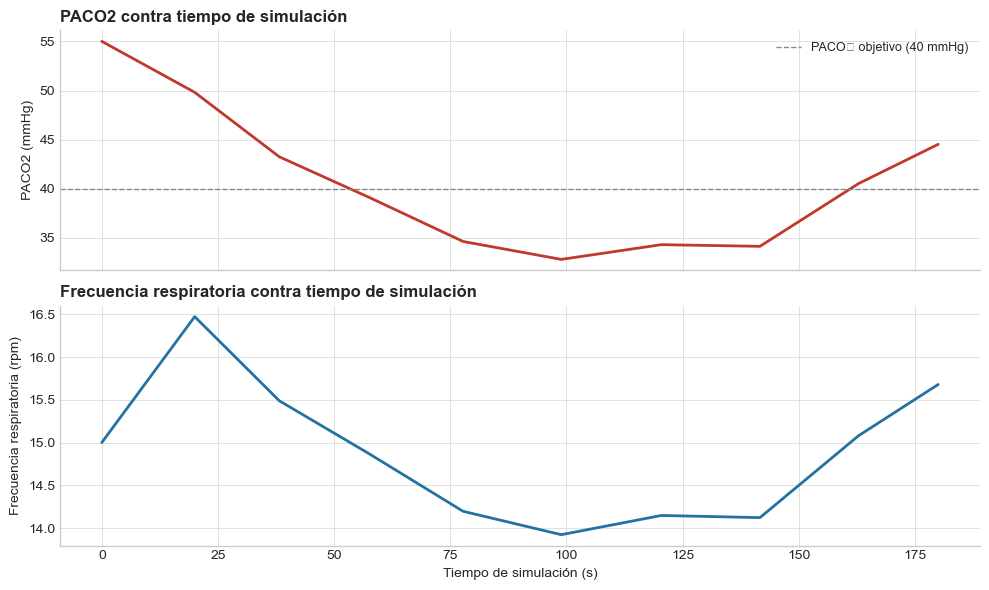

In [27]:
# Figura 24 — Control ESP, convergencia desde PACO₂ = 55 mmHg:

pac   = Paciente(R1=5.0, C1=0.05, R2=5.0, C2=0.05)
vent  = Ventilador(modo='ESP', PEEP=5.0, Ti=1.0, fr=15.0)
ctrl  = ControlRespiratorio(PACO2_target=40.0, f_base=15.0,
                           amplitud_base=5.0, Gp=0.1, Gf=0.15, Gi=0.05)
sim   = Simulador(pac, vent, ctrl)
gases = IntercambioGases(vent, V_D=0.150, VCO2=200.0, R=0.8, FiO2=0.21, Pb=760.0)

T_sim    = 180.0;  dt_fis = 3.0
t_global = 0.0
V0       = [vent.PEEP * pac.C1, vent.PEEP * pac.C2]
PACO2    = 55.0     # condición inicial hipercápnica

hist_t   = [0.0];  hist_co2 = [PACO2];  hist_fr = [vent.fr]

while t_global < T_sim:
    dur = min(5.0 * vent.T_total, T_sim - t_global)
    n   = max(60, int(np.ceil(dur * 50)))
    te  = np.linspace(t_global, t_global + dur, n)
    
    sol = solve_ivp(sim._modelo_edo, [t_global, t_global + dur], V0, t_eval=te, method='RK45')
    V0  = sol.y[:, -1]
    rm  = sim.procesar_resultados(sol.t, sol.y[0], sol.y[1])

    try:
        rg = gases.calcular(rm);  nueva_co2 = rg['PACO2_mmHg']
    except ValueError:
        nueva_co2 = PACO2 + 2.0
    
    PACO2 = 0.3 * nueva_co2 + 0.7 * PACO2
    ctrl.actualizar(PACO2, dt=dt_fis)
    vent.fr      = ctrl.frecuencia * 60.0
    vent.T_total = 60.0 / vent.fr
    vent.Ti      = vent.T_total / 3.0
    
    t_global += dur
    hist_t.append(t_global);  hist_co2.append(PACO2);  hist_fr.append(vent.fr)

hist_t = np.array(hist_t);  hist_co2 = np.array(hist_co2);  hist_fr = np.array(hist_fr)

fig24, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for ax in axs:
    _est(ax)

axs[0].plot(hist_t, hist_co2, color=C_PRESION, lw=2.0)
axs[0].axhline(40.0, color=C_REF, lw=1.0, ls='--', label='PACO₂ objetivo (40 mmHg)')
axs[0].set_ylabel('PACO2 (mmHg)')
axs[0].set_title('PACO2 contra tiempo de simulación', loc='left', fontweight='bold')
axs[0].legend(fontsize=9)

axs[1].plot(hist_t, hist_fr, color=C_FLUJO, lw=2.0)
axs[1].set_ylabel('Frecuencia respiratoria (rpm)')
axs[1].set_xlabel('Tiempo de simulación (s)')
axs[1].set_title('Frecuencia respiratoria contra tiempo de simulación',
               loc='left', fontweight='bold')

plt.tight_layout()
# fig24.savefig('/Users/julianquintana/Desktop/figura_24.png', dpi=150, bbox_inches='tight')
plt.show()